# Parameter estimation for translational protein sector
This notebook was used to estimate the parameters for the translational protein sector as used in the revised proteome allocation model.

**Author: Samira L. van den Bogaard**

### Setting up the notebook environment

In [1]:
#package
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from cobra.io import read_sbml_model
import datetime

from PAModelpy import TransEnzymeSector, PAModel, Config

if os.path.split(os.getcwd())[1] == 'i1_preprocessing':
    os.chdir('../..')

from Modules.utils.sector_config_functions import (perform_linear_regression,
                                                                        reset_translational_sector,
                                                                        plot_translational_protein_vs_mu,
                                                                        get_model_simulations_vs_sector,
                                                  )
from Scripts.pam_generation import setup_sof1_pam
from Modules.utils.pamparametrizer_setup import save_sector_information_to_excel

Loading PAModelpy modules version 0.0.4.9
Set parameter Username
Academic license - for non-commercial use only - expires 2026-03-03


In [2]:
#constants
#files and file paths
DATA_FILE_PATH = os.path.join('Data', 'SoF1_phenotypes','cnecator_proteomics_ribosome_jahn2021.csv')
PAM_DATA_FILE_PATH = os.path.join('Data', 'proteinAllocationModel_EnzymaticData_empty.xlsx')
RESULT_FIG_PATH = os.path.join('Results','figures', 'translational_sector.png')
MODEL_FILE_PATH = os.path.join('Models', '250521_iABA974_kegg_bjp.sbml')

#output file path
# Create a datetime object for the current date
current_date = datetime.datetime.now()
# Format the date as yymmdd
formatted_date = current_date.strftime('%y%m%d')

OUTPUT_FILE_PATH = os.path.join('Scripts','SoF1','Results', 
                                '1_preprocessing', 
                                f'proteinAllocationModel_iABA974_EnzymaticData_{formatted_date}.xlsx')

#defaults from literature
TOTAL_PROTEIN_FRACTION = 0.67836 #[g_prot/g_cdw] from SF measurements (sum of all aa)
MEASURED_PROTEIN_FRACTION = 0.99#g_prot/g_cdw was measured in by Jahn et al.
MODELED_PROTEIN_FRACTION = 1-0.38# according to Jahn et al, which makes an RBA model also including transcription. But it seems that the transcription machinery does not account for much protein space (see fig2)
metabolic_protein_fraction = TOTAL_PROTEIN_FRACTION*MODELED_PROTEIN_FRACTION

SUBSTRATE_UPTAKE_RXN_ID = 'EX_co2_e'
BIOMASS_RXN_ID = 'Growth'

### Configure parameters and data
Quantitative proteomics for SoF1 is missing, but there is proteomics data for C.necator available from [Jahn et al., 2021](https://pmc.ncbi.nlm.nih.gov/articles/PMC8591527/#s4), via their [Shiny app](https://m-jahn.shinyapps.io/ShinyProt. They mentioned that 99% of all proteins by mass was measured, and that on average 38% of the measured protein was not modeled in their RBA model. An RBA model also includes proteins involved in transcription, but according to Fig 2, the contribution of transcription machinery to the protein mass was neglegible.

The proteomics data for SoF1 is not quantitative, but can be used to estimate the correctness (TODO)

In [3]:
cnecator_ribosome = pd.read_csv(DATA_FILE_PATH)[['substrate', 'growthrate', 'mass_g_per_gDCW']]
#exclude nitrogen limitation as this affects the ribsome-to-growthrate relation
cnecator_ribosome_summed = cnecator_ribosome[
    cnecator_ribosome.substrate !='ammonium'
].groupby(['substrate', 'growthrate']).sum().reset_index()
cnecator_ribosome_summed

,substrate,growthrate,mass_g_per_gDCW
0,formate,0.05,0.023964
1,formate,0.10,0.030234
2,formate,0.15,0.031364
3,formate,0.20,0.038980
4,formate,0.25,0.040330
5,fructose,0.05,0.033633
6,fructose,0.10,0.036646
7,fructose,0.15,0.043705
8,fructose,0.20,0.044683
9,fructose,0.25,0.047611


The slope and intercept are derived from proteome measurements. We know these measurement are related to a total protein concentration of 0.32 g/g_cdw. This is why we need to correct the slope and intercept when it it incorporated into the model.

In [4]:
#get the relation with growth rate
transl_sector_per_substrate = {}
for csource, df in cnecator_ribosome_summed.reset_index().groupby('substrate'):
    slope, intercept = perform_linear_regression(x=df['growthrate'],
                                                 y=df['mass_g_per_gDCW']/100*MEASURED_PROTEIN_FRACTION/metabolic_protein_fraction)

    print(f'Translational sector vs growth rate using data from Jahn et al(2021) for {csource}: \n\tIntercept: ',intercept*MEASURED_PROTEIN_FRACTION, 'g/g_cdw')
    print('\tSlope: ',slope*MEASURED_PROTEIN_FRACTION, 'g/g_cdw/h')
    transl_sector_per_substrate[csource] = {'slope': slope, 'intercept': intercept}

Translational sector vs growth rate using data from Jahn et al(2021) for formate: 
	Intercept:  0.00047844655403904944 g/g_cdw
	Slope:  0.0019330980571499916 g/g_cdw/h
Translational sector vs growth rate using data from Jahn et al(2021) for fructose: 
	Intercept:  0.0007097674970768825 g/g_cdw
	Slope:  0.001677509127667794 g/g_cdw/h
Translational sector vs growth rate using data from Jahn et al(2021) for succinate: 
	Intercept:  0.0004163037926043645 g/g_cdw
	Slope:  0.0031303681024352787 g/g_cdw/h


In [5]:
slope, intercept = perform_linear_regression(x=cnecator_ribosome_summed['growthrate'],
                                                 y=cnecator_ribosome_summed['mass_g_per_gDCW']/100*MEASURED_PROTEIN_FRACTION/metabolic_protein_fraction)

print('Translational sector vs growth rate using data from Jahn et al(2021) for all csources: \n\tIntercept: ',intercept*MEASURED_PROTEIN_FRACTION, 'g/g_cdw')
print('\tSlope: ',slope*MEASURED_PROTEIN_FRACTION, 'g/g_cdw/h')

Translational sector vs growth rate using data from Jahn et al(2021) for all csources: 
	Intercept:  0.0005348392812400987 g/g_cdw
	Slope:  0.0022469917624176887 g/g_cdw/h


### Use the mu vs translational protein relationship to perform simulations with the PAM model
The predicted glucose uptake rates can be used to derive the relationship between glucose uptake and translational protein.

In [6]:
#set up model without total protein constraint to just model the linear relation between
id_list_tps = [BIOMASS_RXN_ID]
tps_0 = [intercept]  # g/gDW
tps_mu = [slope]  # g h/gDW 
molmass_tps = [405903.94]  # g/mol

# translational protein sector
translation_enzyme_sector = TransEnzymeSector(
            id_list=id_list_tps,
            tps_0=tps_0,
            tps_mu=tps_mu,
            mol_mass=molmass_tps,
        )

In [7]:
#setup a basic PAModel with the new translational sector
model = read_sbml_model(MODEL_FILE_PATH)
config = Config()
config.reset()
config.BIOMASS_REACTION = BIOMASS_RXN_ID

pamodel = PAModel(id_or_model = model,
                  p_tot=False, 
                  translational_sector = translation_enzyme_sector,
                  configuration = config,
                  sensitivity = False) # sensitivity disabled to speed things up
#get parameters
translational_sector = pamodel.sectors.get_by_id('TranslationalProteinSector')
tps_molmass = translational_sector.mol_mass[0]

Setting up the proteome allocation model mergem_model_gramneg

Total condition-dependent protein constraint is not added 

Add the following protein sector: TranslationalProteinSector

Done with setting up the proteome allocation model mergem_model_gramneg



In [8]:
#adjust relation in model
trans_sector = pamodel.sectors.get_by_id('TranslationalProteinSector')

#adjust the translational protein sector
pamodel.change_sector_parameters(trans_sector, slope*MEASURED_PROTEIN_FRACTION,
                                 intercept*MEASURED_PROTEIN_FRACTION, lin_rxn_id = BIOMASS_RXN_ID)

In [9]:
#run the model
substrate_range = np.arange(-10,1,1)

#we shouldn't correct for measured total protein here, as we are comparing it to the measured data
simulation_results_bms = get_model_simulations_vs_sector(pamodel, SUBSTRATE_UPTAKE_RXN_ID, BIOMASS_RXN_ID,
                                           substrate_range, intercept,slope) 


Running simulations with  -10 mmol/g_cdw/h of substrate going into the system
Running simulations with  -9 mmol/g_cdw/h of substrate going into the system
Running simulations with  -8 mmol/g_cdw/h of substrate going into the system
Running simulations with  -7 mmol/g_cdw/h of substrate going into the system
Running simulations with  -6 mmol/g_cdw/h of substrate going into the system
Running simulations with  -5 mmol/g_cdw/h of substrate going into the system
Running simulations with  -4 mmol/g_cdw/h of substrate going into the system
Running simulations with  -3 mmol/g_cdw/h of substrate going into the system
Running simulations with  -2 mmol/g_cdw/h of substrate going into the system
Running simulations with  -1 mmol/g_cdw/h of substrate going into the system
Running simulations with  0 mmol/g_cdw/h of substrate going into the system


In [10]:
#derive the relation to glucose uptake rate
#results are in g_transprot/g_prot and need to be converted to g/gcdw (glucose uptake should stay in mmol for compatibility with model)
slope_glc, intercept_glc = perform_linear_regression(
    x=simulation_results_bms[SUBSTRATE_UPTAKE_RXN_ID], y=simulation_results_bms['translational_protein'])

print('Translational sector vs glucose uptake using data from Schmidt et al (2016): \n Intercept: ',intercept_glc *MEASURED_PROTEIN_FRACTION, ' g/g_cdw')
print('Slope: ',slope_glc*MEASURED_PROTEIN_FRACTION, ' g/mmol_susbstrate/h')


Translational sector vs glucose uptake using data from Schmidt et al (2016): 
 Intercept:  0.0005348392812400989  g/g_cdw
Slope:  -4.7041535547973114e-05  g/mmol_susbstrate/h


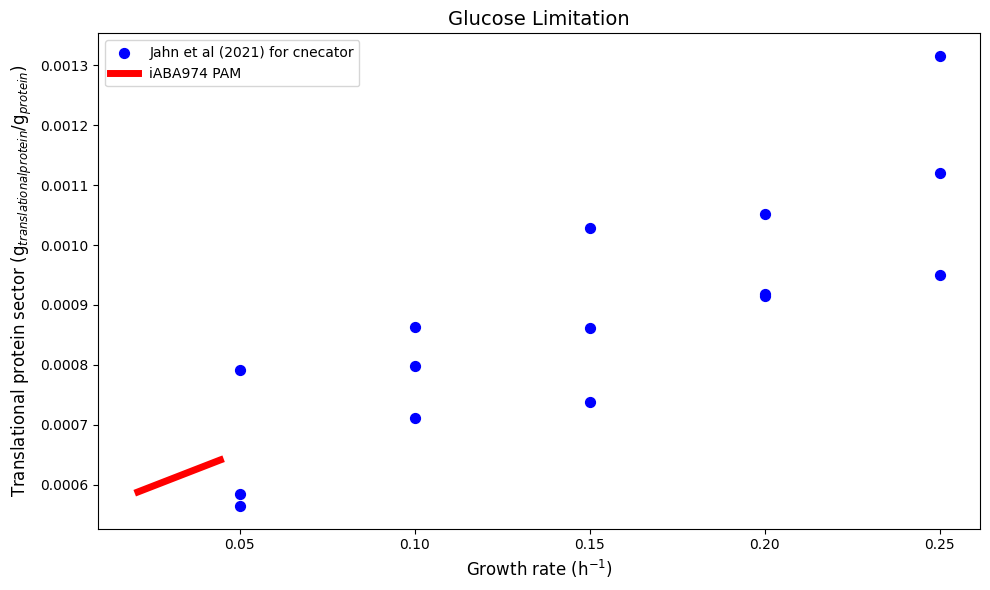

In [11]:
#visualization of results
plot_translational_protein_vs_mu(cnecator_ribosome_summed.rename({
    'growthrate': 'Experimental Growth rate',
    'mass_g_per_gDCW': 'Translation, ribosomal structure and biogenesis'
}, axis=1),
                                 simulation_results_bms, 
                                 protein_fraction = metabolic_protein_fraction, 
                                 measured_protein_fraction=MEASURED_PROTEIN_FRACTION,
                                 configuration = config,
                                 oxygen_results = None,
                                literature_label = 'Jahn et al (2021) for cnecator',
                                model_label='iABA974 PAM')

### Use the glucose vs translational protein relationship to perform simulations with the PAM model with only the translational protein sector

The result will be compared to the experimental data. The slope and intercept are derived from proteome measurements. We know these measurement are related to a total protein concentration of 0.32 g/g_cdw. This is why we need to correct the slope and intercept when it it incorporated into the model. In the comparison, this correction is not required.

In [12]:
#change the translational sector parameters
trans_sector = pamodel.sectors.get_by_id('TranslationalProteinSector')

pamodel.change_sector_parameters(trans_sector, slope_glc*MEASURED_PROTEIN_FRACTION,
                                 intercept_glc*MEASURED_PROTEIN_FRACTION, 
                                        lin_rxn_id = SUBSTRATE_UPTAKE_RXN_ID)

In [13]:
simulation_results_co2 = get_model_simulations_vs_sector(pamodel, 
                                                         SUBSTRATE_UPTAKE_RXN_ID, 
                                                         SUBSTRATE_UPTAKE_RXN_ID,
                                                         substrate_range, 
                                                         intercept_glc, slope_glc, 
                                                         to_save = BIOMASS_RXN_ID
                                                        )

Running simulations with  -10 mmol/g_cdw/h of substrate going into the system
Running simulations with  -9 mmol/g_cdw/h of substrate going into the system
Running simulations with  -8 mmol/g_cdw/h of substrate going into the system
Running simulations with  -7 mmol/g_cdw/h of substrate going into the system
Running simulations with  -6 mmol/g_cdw/h of substrate going into the system
Running simulations with  -5 mmol/g_cdw/h of substrate going into the system
Running simulations with  -4 mmol/g_cdw/h of substrate going into the system
Running simulations with  -3 mmol/g_cdw/h of substrate going into the system
Running simulations with  -2 mmol/g_cdw/h of substrate going into the system
Running simulations with  -1 mmol/g_cdw/h of substrate going into the system
Running simulations with  0 mmol/g_cdw/h of substrate going into the system


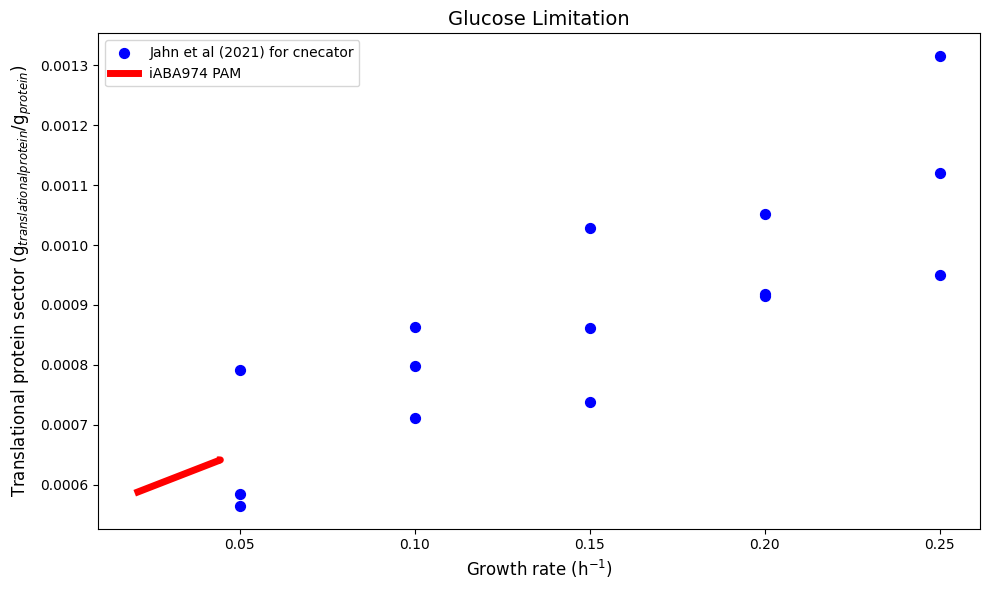

In [14]:
#visualize results
plot_translational_protein_vs_mu(cnecator_ribosome_summed.rename({
    'growthrate': 'Experimental Growth rate',
    'mass_g_per_gDCW': 'Translation, ribosomal structure and biogenesis'
}, axis=1), simulation_results_co2,
                                 protein_fraction = metabolic_protein_fraction, 
                                 measured_protein_fraction=MEASURED_PROTEIN_FRACTION,
                                 configuration = config,
                                 oxygen_results = None,
                                literature_label = 'Jahn et al (2021) for cnecator',
                                model_label='iABA974 PAM')

In [15]:
# save to excel
save_sector_information_to_excel(
        param_vs_lin_rxn={
            'slope': slope_glc*MEASURED_PROTEIN_FRACTION,
            'intercept': intercept_glc*MEASURED_PROTEIN_FRACTION
        },
        param_vs_growth={
            'slope': slope*MEASURED_PROTEIN_FRACTION,
            'intercept': intercept*MEASURED_PROTEIN_FRACTION
        },
        biomass_rxn=config.BIOMASS_REACTION,
        lin_rxn_id='EX_co2_e',
        sector_id='Translational',
        pam_data_file=PAM_DATA_FILE_PATH,
    model_name = 'iABA974')

## Unused protein sector

To configure the unused protein sector, the percentage increase of the max growth rate from a *C.necator* strain subjected to adaptive laboratory evolution for growth on formate ([Calvey et al., 2023.](https://www.sciencedirect.com/science/article/pii/S1096717622001355#sec3), Supplementary Table S5) was used, as similar experiments for growth on CO2 or with a xanthobacter strain was not available.

MAX_MU_CN = 0.080
MAX_MU_CN_ALE = 0.112

In [16]:
#from C.necator on CH3 Calvey et al., 2023
MAX_MU_CN = 0.080 #h-1
MAX_MU_CN_ALE = 0.112 #h-1
#From E. coli (Bruggeman et al., 2020)
UNUSED_PROTEIN_INTERCEPT = 0.37 #g_unusedprotein/g_protein
#From SF measurements
MAX_MU_SOF1 = 0.05#h-1

In [17]:
est_max_mu_ale_sof1 = MAX_MU_SOF1*MAX_MU_CN_ALE/MAX_MU_CN

In [18]:
# save to excel
save_sector_information_to_excel(
        param_vs_lin_rxn={
            'slope': 0,
            'intercept': 0
        },
        param_vs_growth={
            'slope': -UNUSED_PROTEIN_INTERCEPT/est_max_mu_ale_sof1,
            'intercept': UNUSED_PROTEIN_INTERCEPT*MODELED_PROTEIN_FRACTION
        
        },
        biomass_rxn=config.BIOMASS_REACTION,
        lin_rxn_id='EX_co2_e',
        sector_id='UnusedEnzyme',
        pam_data_file=PAM_DATA_FILE_PATH,
    model_name = 'iABA974')

In [19]:
# pamodel.sensitivity = True
pamodel.change_reaction_bounds('EX_co2_e', 0,0)
pamodel.change_reaction_bounds('EX_succ_e', -1,0)
pamodel.change_reaction_bounds('EX_h_e', -19.4,0)
pamodel.optimize()

,fluxes,reduced_costs
EX_25dkglcn_e,0.000000,-2.512241e-01
EX_2ameph_e,0.000000,-8.374136e-02
EX_2m35mdntha_e,0.000000,0.000000e+00
EX_2pglyc_e,0.000000,-8.374136e-02
EX_34dhbz_e,0.000000,-2.930948e-01
...,...,...
FACOAE1836Z9Z12Z,0.000030,0.000000e+00
NIT,0.000000,8.881784e-16
FERHYD,0.000000,0.000000e+00
CYTHYD,0.000000,0.000000e+00


In [20]:
pamodel.capacity_sensitivity_coefficients.sort_values('coefficient')

KeyError: 'coefficient'